In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [7]:
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
CSV = "measurements_mm.csv"
df = pd.read_csv(CSV)

for col in ["total_time_s", "avg_worker_comm_s", "avg_worker_comp_s"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.4,
})
 
COLORS = {
    "total_time_s":       "#4C72B0",
    "avg_worker_comm_s":  "#DD8452",
    "avg_worker_comp_s":  "#55A868",
}
LABELS = {
    "total_time_s":       "Total (master)",
    "avg_worker_comm_s":  "Avg worker comm",
    "avg_worker_comp_s":  "Avg worker comp",
}
 

Saved plots/ex10_performance.png


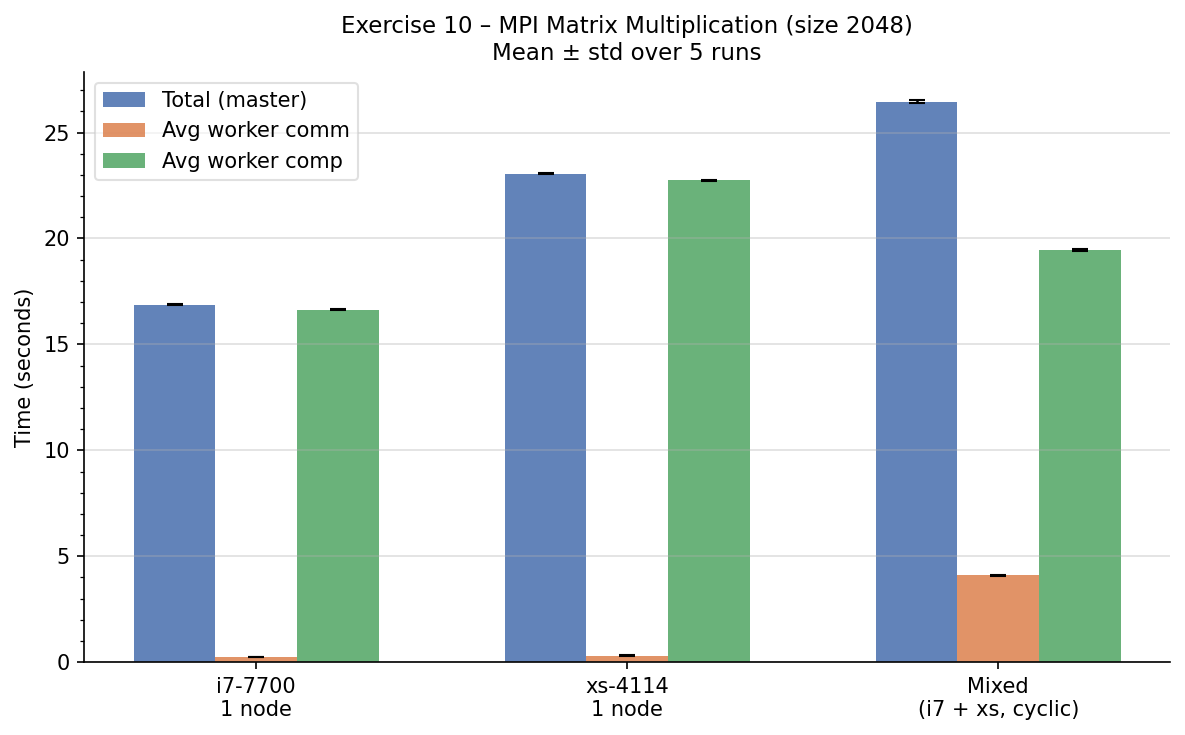

In [9]:
ex10 = df[df["config"].str.startswith("ex10")].copy()
 
# Prettier x-axis labels
label_map = {
    "ex10_i7-7700_1node":       "i7-7700\n1 node",
    "ex10_xs-4114_1node":       "xs-4114\n1 node",
    "ex10_mixed_2nodes_cyclic": "Mixed\n(i7 + xs, cyclic)",
}
ex10["label"] = ex10["config"].map(label_map)
 
# Aggregate: mean ± std over runs
agg = (
    ex10
    .groupby("label")[["total_time_s", "avg_worker_comm_s", "avg_worker_comp_s"]]
    .agg(["mean", "std"])
)
 
metrics   = ["total_time_s", "avg_worker_comm_s", "avg_worker_comp_s"]
configs   = list(label_map.values())
x         = np.arange(len(configs))
bar_w     = 0.22
offsets   = np.array([-1, 0, 1]) * bar_w
 
fig1, ax1 = plt.subplots(figsize=(8, 5))
 
for offset, metric in zip(offsets, metrics):
    means = [agg.loc[c, (metric, "mean")] if c in agg.index else np.nan for c in configs]
    stds  = [agg.loc[c, (metric, "std")]  if c in agg.index else np.nan for c in configs]
    ax1.bar(
        x + offset, means, bar_w,
        yerr=stds, capsize=4,
        label=LABELS[metric],
        color=COLORS[metric],
        alpha=0.88,
        error_kw={"elinewidth": 1.2, "ecolor": "black"},
    )
 
ax1.set_xticks(x)
ax1.set_xticklabels(configs)
ax1.set_ylabel("Time (seconds)")
ax1.set_title(
    f"Exercise 10 – MPI Matrix Multiplication (size {ex10['matrix_size'].iloc[0]})\n"
    "Mean ± std over 5 runs",
    fontsize=11,
)
ax1.legend(framealpha=0.6)
ax1.yaxis.set_minor_locator(mticker.AutoMinorLocator())
 
fig1.tight_layout()
fig1.savefig(PLOTS_DIR / "ex10_performance.png")
print("Saved plots/ex10_performance.png")

Saved plots/ex11_overcommit.png


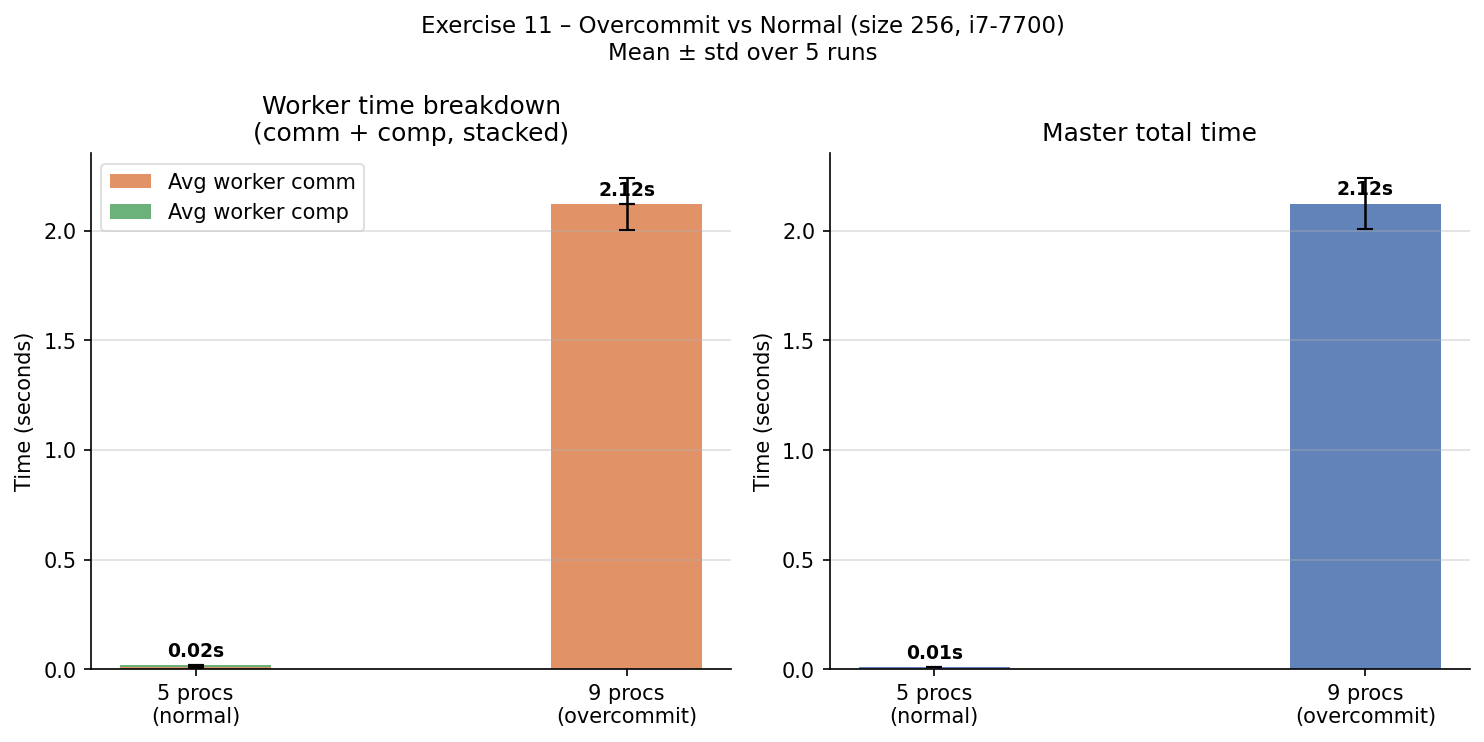

In [10]:
ex11 = df[df["config"].str.startswith("ex11")].copy()
 
label_map11 = {
    "ex11_5proc_normal":    "5 procs\n(normal)",
    "ex11_9proc_overcommit": "9 procs\n(overcommit)",
}
ex11["label"] = ex11["config"].map(label_map11)
 
agg11 = (
    ex11
    .groupby("label")[["total_time_s", "avg_worker_comm_s", "avg_worker_comp_s"]]
    .agg(["mean", "std"])
)
 
configs11 = list(label_map11.values())
x11       = np.arange(len(configs11))
bar_w11   = 0.35
 
comm_means = [agg11.loc[c, ("avg_worker_comm_s", "mean")] if c in agg11.index else 0 for c in configs11]
comp_means = [agg11.loc[c, ("avg_worker_comp_s", "mean")] if c in agg11.index else 0 for c in configs11]
comm_stds  = [agg11.loc[c, ("avg_worker_comm_s", "std")]  if c in agg11.index else 0 for c in configs11]
comp_stds  = [agg11.loc[c, ("avg_worker_comp_s", "std")]  if c in agg11.index else 0 for c in configs11]
total_means= [agg11.loc[c, ("total_time_s",       "mean")] if c in agg11.index else 0 for c in configs11]
total_stds = [agg11.loc[c, ("total_time_s",       "std")]  if c in agg11.index else 0 for c in configs11]
 
fig2, axes = plt.subplots(1, 2, figsize=(10, 5))
 
# Left: stacked worker time (comm + comp) per config
ax_stack = axes[0]
bars_comm = ax_stack.bar(
    x11, comm_means, bar_w11,
    label="Avg worker comm",
    color=COLORS["avg_worker_comm_s"], alpha=0.88,
    yerr=comm_stds, capsize=4,
    error_kw={"elinewidth": 1.2, "ecolor": "black"},
)
bars_comp = ax_stack.bar(
    x11, comp_means, bar_w11,
    bottom=comm_means,
    label="Avg worker comp",
    color=COLORS["avg_worker_comp_s"], alpha=0.88,
    yerr=comp_stds, capsize=4,
    error_kw={"elinewidth": 1.2, "ecolor": "black"},
)
ax_stack.set_xticks(x11)
ax_stack.set_xticklabels(configs11)
ax_stack.set_ylabel("Time (seconds)")
ax_stack.set_title("Worker time breakdown\n(comm + comp, stacked)")
ax_stack.legend(framealpha=0.6)
 
# Right: master total time
ax_total = axes[1]
ax_total.bar(
    x11, total_means, bar_w11,
    yerr=total_stds, capsize=4,
    color=COLORS["total_time_s"], alpha=0.88,
    error_kw={"elinewidth": 1.2, "ecolor": "black"},
)
ax_total.set_xticks(x11)
ax_total.set_xticklabels(configs11)
ax_total.set_ylabel("Time (seconds)")
ax_total.set_title("Master total time")
 
# Annotate bars with exact mean values
for ax, means in [(ax_stack, [c + p for c, p in zip(comm_means, comp_means)]),
                  (ax_total, total_means)]:
    for xi, m in zip(x11, means):
        ax.text(xi, m + 0.01 * max(means), f"{m:.2f}s",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
 
fig2.suptitle(
    f"Exercise 11 – Overcommit vs Normal (size {ex11['matrix_size'].iloc[0]}, i7-7700)\n"
    "Mean ± std over 5 runs",
    fontsize=11,
)
fig2.tight_layout()
fig2.savefig(PLOTS_DIR / "ex11_overcommit.png")
print("Saved plots/ex11_overcommit.png")